In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# generalized Hilbert matrix
# kernel: sgn*sin((1+d)*pi)/(pi*(n+m+1+d)) for n,m = 0,1,2,...,n-1
def gen_hilbert_matrix(n,d,sgn):
    M = np.zeros((n,n))
    for k in range(n):
        for m in range(n):
            M[k,m] = sgn*np.sin((1.0 + d)*np.pi)/(np.pi*(k + m + 1.0 + d))
            # M[k,m] = 1.0/(np.pi*(k + m + 1.0))
    for k in range(n):
        M[k,k] += 0 # 1
    return M

# compute identity minus a square matrix M
def identity_minus_matrix(M):
    M = np.asarray(M)
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError("Input must be a square 2D matrix.")
    return np.eye(M.shape[0], dtype=M.dtype) - M


In [25]:
# example 
np.set_printoptions(precision=4, suppress=True, linewidth=100)

# Example 1 - d=-0.5
print(gen_hilbert_matrix(10,-0.5,1.0))

print("--------------------------------")
print("--------------------------------")

# Example 2 - d = -2.5
print(gen_hilbert_matrix(10,-2.5,1.0))

# you see that the first matrix is a sub matrix of the second matrix. -> I think for any proof this should be used

[[0.6366 0.2122 0.1273 0.0909 0.0707 0.0579 0.049  0.0424 0.0374 0.0335]
 [0.2122 0.1273 0.0909 0.0707 0.0579 0.049  0.0424 0.0374 0.0335 0.0303]
 [0.1273 0.0909 0.0707 0.0579 0.049  0.0424 0.0374 0.0335 0.0303 0.0277]
 [0.0909 0.0707 0.0579 0.049  0.0424 0.0374 0.0335 0.0303 0.0277 0.0255]
 [0.0707 0.0579 0.049  0.0424 0.0374 0.0335 0.0303 0.0277 0.0255 0.0236]
 [0.0579 0.049  0.0424 0.0374 0.0335 0.0303 0.0277 0.0255 0.0236 0.022 ]
 [0.049  0.0424 0.0374 0.0335 0.0303 0.0277 0.0255 0.0236 0.022  0.0205]
 [0.0424 0.0374 0.0335 0.0303 0.0277 0.0255 0.0236 0.022  0.0205 0.0193]
 [0.0374 0.0335 0.0303 0.0277 0.0255 0.0236 0.022  0.0205 0.0193 0.0182]
 [0.0335 0.0303 0.0277 0.0255 0.0236 0.022  0.0205 0.0193 0.0182 0.0172]]
--------------------------------
--------------------------------
[[-0.2122 -0.6366  0.6366  0.2122  0.1273  0.0909  0.0707  0.0579  0.049   0.0424]
 [-0.6366  0.6366  0.2122  0.1273  0.0909  0.0707  0.0579  0.049   0.0424  0.0374]
 [ 0.6366  0.2122  0.1273  0.0909  0.

I'm interested in the asymptotic behavior of the determinants 

i) $\det(I - M_n(d)^2)$ 

ii) $\det(I - M_n(d))$ 

iii) $\det(I + M_(d))$ 

where $M(d)_n = gen_hilbert_matrix(n, d, 1.0) as $n \to \infty$. For i) we conjecture 

$\lim_{n\to\infty} \det(I - M_n(d)^2) / n^{-d^2} $

exists, i.e $\det(I - M_n(d)^2) \sim n^{-d^2} $ as $n\to\infty$. I don't know the answer for ii) and iii) but of course

$\det(I - M_n(d)^2) = \det(I + M_n(d)) \det(I - M_n(d))$

i.e. the product of the asymptotics of the un-squared matrices must be the asymptotics of the squared matrix. 

### Basic asymptotic analysis of the determinant of the generalized Hilbert Mm

In [7]:
a = -0.5

for n in[100, 500, 1000, 2000,4000]:
    M = gen_hilbert_matrix(n,a,1)
    M_sq = M @ M
    id_minus_M_sq = identity_minus_matrix(M_sq)
    print(np.linalg.det(id_minus_M_sq) * n**(a*a))

0.5659634557070372
0.5656800205740771
0.5656446407239341
0.5656269569697339
0.5656181169218812


In [13]:
a = -1.5

for n in[100, 500, 1000, 2000,4000]:
    M = gen_hilbert_matrix(n,a,1)
    M_sq = M @ M
    id_minus_M_sq = identity_minus_matrix(M_sq)
    print(np.linalg.det(id_minus_M_sq) * n**(a*a))



0.05647632527880769
0.05571639559295682
0.055622371769577086
0.05557543915814017
0.055551989421498756


In [18]:
# this one is really weird: It gets negative. I believe there is some numerical instability going on here. The determinant should be positive, but it is not. I will try to compute the determinant of the matrix M_sq and see if it is positive or negative. If it is negative, then the determinant of id_minus_M_sq will be negative as well. If it is positive, then the determinant of id_minus_M_sq will be positive as well.
a = -3.3

for n in[100, 500, 1000, 2000,4000]:
    M = gen_hilbert_matrix(n,a,1)
    M_sq = M @ M
    id_minus_M_sq = identity_minus_matrix(M_sq)
    print(np.linalg.det(id_minus_M_sq) * n**(a*a))

0.00019662316925104115
0.013930772704348126
0.5882829983385176
28.603736472246382
969.4319295965536


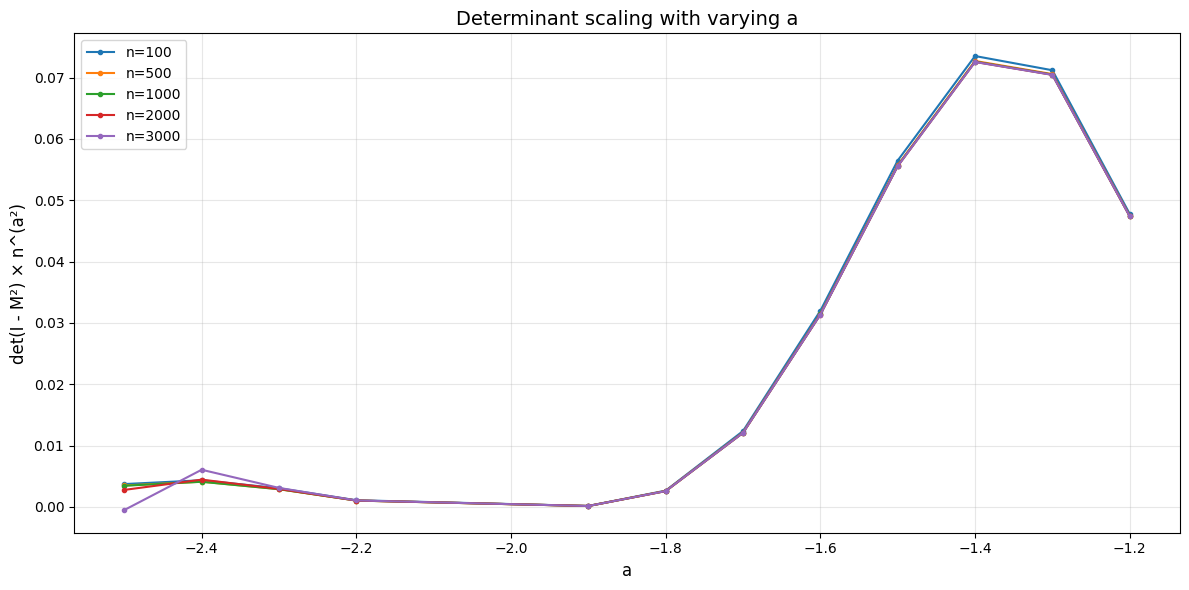

In [ ]:
# plot the value of det(I - M^2) * n^(a^2) as a function of a
# plot this function for n = 100, 500, 1000, 2000, 3000


# Define the range of 'a' values (excluding negative integers)
a_values = np.concatenate([
    np.arange(-2.5, -2.1, 0.1),
    np.arange(-1.9, -1.1, 0.1),
])
# Remove any exact negative integers
a_values = a_values[~np.isin(a_values, np.arange(-5, 0))]

n_values = [100, 500, 1000, 2000, 3000]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for n in n_values:
    results = []
    for a in a_values:
        M = gen_hilbert_matrix(n, a, 1)
        M_sq = M @ M
        id_minus_M_sq = identity_minus_matrix(M_sq)
        result = np.linalg.det(id_minus_M_sq) * n**(a*a)
        results.append(result)
    
    ax.plot(a_values, results, label=f'n={n}', marker='o', markersize=3)

ax.set_xlabel('a', fontsize=12)
ax.set_ylabel(f'det(I - M²) × n^(a²)', fontsize=12)
ax.set_title('Determinant scaling with varying a', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Some References

https://arxiv.org/abs/1808.08009 -> that's my paper but only an analysis of powers of traces, no change to get the above asymptotics from the methods there. 

https://arxiv.org/abs/2207.11029 -> Peter Otte :) but I think not really related 

https://arxiv.org/abs/1506.01064 -> diagonalization of the generalized Hilbert matrix 

There are probably many more papers


